## Plotting and testing of all three GMRES implementations
### Dylan Sheridan 20330976

Link to github repo : https://github.com/DylShero/CaseStudiesAssignment2

### Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import mmread
import time

from GMRES_functions import gmres_basic, gmres_givens, gmres_no_build

## Function to test and plot on both small and large test matrices

Calls all three different GMRES solvers on a given input matrix

In [12]:
def run_solver_comparison(A, b, matrix_name, max_iter_allowed):
    """
    Runs all three GMRES implementations on the small and large test matrices and plots them together.
    """
    print(f"\n{'='*50}")
    print(f"Testing Matrix: {matrix_name} (Size: {A.shape[0]} x {A.shape[1]})")
    print(f"Maximum iterations capped at: {max_iter_allowed}")
    print(f"{'='*50}")
    
    # Dictionary of the functions
    solvers = {
        "Basic GMRES (lstsq)": gmres_basic,
        "Givens Rotations": gmres_givens,
        "No-Build": gmres_no_build
    }
    
    # Setup for plotting
    plt.figure(figsize=(10, 6))
    colors = ['red', 'blue', 'green']
    markers = ['o', 's', '^']
    
    # Loop through each function and time it
    for i, (name, solver_func) in enumerate(solvers.items()):
        print(f"Running {name}...")
        
        start_time = time.time()
        # Run the specific solver
        x, res_history = solver_func(A, b, max_iter=max_iter_allowed)
        end_time = time.time()
        
        elapsed_time = end_time - start_time
        total_iters = len(res_history) - 1
        final_res = res_history[-1]
        
        # Print the stats
        print(f"  -> Iters : {total_iters}")
        print(f"  -> Time  : {elapsed_time:.4f} seconds")
        print(f"  -> Final Res: {final_res:.2e}\n")
        
        # Add to the combined plot
        plt.semilogy(res_history, marker=markers[i], linestyle='-', 
                     color=colors[i], markersize=4, label=f"{name} ({elapsed_time:.2f}s)")

    # Finalize the plot
    plt.title(f'GMRES Comparison: {matrix_name}')
    plt.xlabel('Iteration')
    plt.ylabel('Residual Norm ||r_m||_2')
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend()
    plt.show()


## Small matrix test

Calls the above function on the given small test matrix and compares timings.


Testing Matrix: Small Matrix (Size: 961 x 961)
Maximum iterations capped at: 200
Running Basic GMRES (lstsq)...
  -> Iters : 80
  -> Time  : 0.1043 seconds
  -> Final Res: 5.03e-09

Running Givens Rotations...
  -> Iters : 80
  -> Time  : 0.0400 seconds
  -> Final Res: 5.03e-09

Running No-Build...
  -> Iters : 80
  -> Time  : 0.0642 seconds
  -> Final Res: 5.03e-09



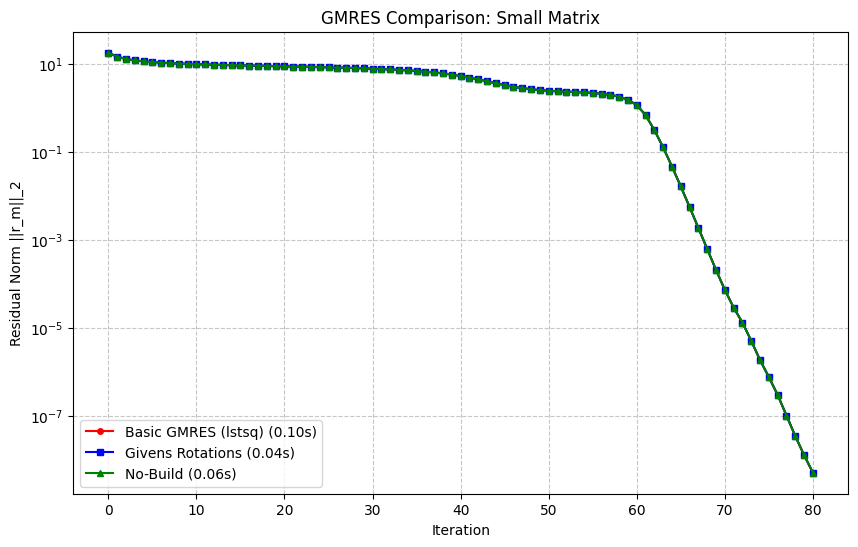

In [13]:
# Test 1: Small Matrix (generated b)
A_small = mmread('cdde6.mtx').tocsr()
n_small = A_small.shape[0]
x_true_small = np.ones(n_small)
b_small = A_small.dot(x_true_small)
        
run_solver_comparison(A_small, b_small, "Small Matrix", max_iter_allowed=min(n_small, 200))

## Large matrix test

Calls the above function on the given large test matrix and compares timings.
Had to use a smaller max iterations of 100 to deal with memory constraints of my laptop.


Testing Matrix: Large Matrix (Size: 525825 x 525825)
Maximum iterations capped at: 100
Running Basic GMRES (lstsq)...
  -> Iters : 100
  -> Time  : 67.7338 seconds
  -> Final Res: 9.34e-05

Running Givens Rotations...
  -> Iters : 100
  -> Time  : 72.8806 seconds
  -> Final Res: 9.34e-05

Running No-Build...
  -> Iters : 100
  -> Time  : 54.1080 seconds
  -> Final Res: 9.34e-05



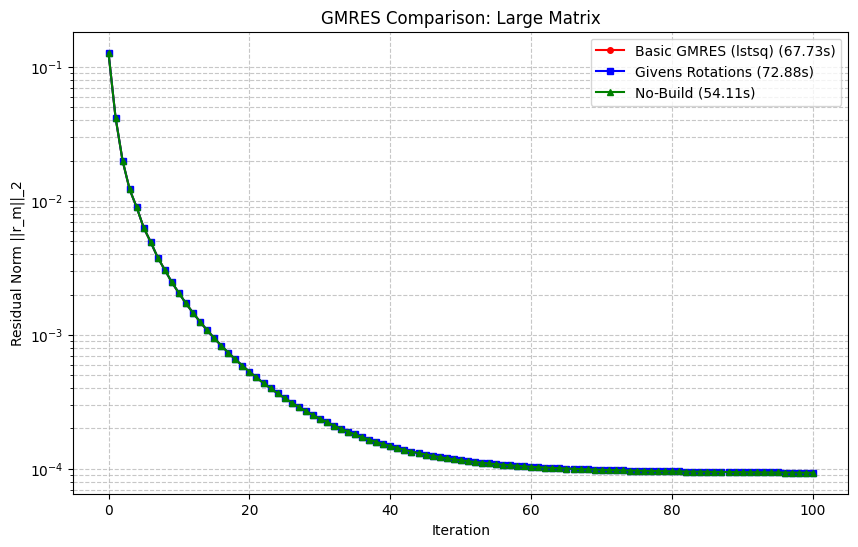

In [14]:
# Test 2: Large Matrix (provided b)
A_large = mmread('parabolic_fem.mtx').tocsr()
n_large = A_large.shape[0]
        
b_raw = mmread('parabolic_fem_b.mtx')

b_large = b_raw.flatten()
            
# Smaller max iterations due to memory constraints
run_solver_comparison(A_large, b_large, "Large Matrix", max_iter_allowed=min(n_large, 100))

## Results

We can see that for the small test matrix each change improved performance. Givens is faster than the basic implementation and the No build is faster than the givens rotation. This changes with the large matrix where the basic implementation actually out performs the givens rotation, but the no build continues to be the best performing of the three on the large matrix. Though the performance difference does narrow between the basic implementation and no build. Being approximately 2.9x faster on the small matrix versus a little over 1.2x faster on the large test matrix.

I think this is due to the change between givens and no_build where as the basic implementation also only builds the final matrix once. Having to build the approx solution vector at each iteration really slows down the performance on the large matrix size when dealing with an approx 500,000 x 500,000 matrix. This is less noticeable on the small matrix so the performance benefit of doing the givens rotation out performs the slow down from building the small approx solution vector at each iteration. The no build gets the benefit of both by only building the approx solution vector once but getting the performance benefit of the givens rotation.